### Matrix Addition

In [1]:
a=[[1,2],
   [3,4]]
b=[[5,-1],
   [0,2]]

add_mat=[]

for i in range(len(a)):
    row=[]
    for j in range(len(b)):
          row.append(a[i][j]+b[i][j])
    add_mat.append(row)
print(add_mat)

[[6, 1], [3, 6]]


### eigen values and eigen vectors from scratch

In [2]:
import math
a,b=2,1
c,d=1,2

trace=a+d
det=a*d-b*c

lambda1=(trace+math.sqrt(trace**2-4*det))/2
lambda2=(trace-math.sqrt(trace**2-4*det))/2

print("Eigenvalue 1:",lambda1)
print("Eigenvalue 2:",lambda2)

def eigenvector(lam):
    if b!=0:
        x = 1
        y = -((a-lam)/b)*x
        return (x,y)
    else:
        x=0
        y = a-lam
        return (x,y)
    
print("Eienvector for lambda1:",eigenvector(lambda1))
print("Eienvector for lambda2:",eigenvector(lambda2))

Eigenvalue 1: 3.0
Eigenvalue 2: 1.0
Eienvector for lambda1: (1, 1.0)
Eienvector for lambda2: (1, -1.0)


In [3]:
X = [2, 4, 6, 8]
Y = [1, 3, 5, 7]

mean_X = sum(X)/len(X)
mean_Y = sum(Y)/len(Y)


var_X = sum((i-mean_X)**2 for i in X) / (len(X)-1)
var_Y = sum((i-mean_X)**2 for i in Y) / (len(Y)-1)

cov_XY = sum((X[i]-mean_X)*(Y[i]-mean_Y) for i in range(len(X))) / (len(X)-1)

cov_matrix = [[var_X,cov_XY],
              [cov_XY,var_Y]]

print("Covariance Matrix (from scratch):")
for i in cov_matrix:
    print(i)

Covariance Matrix (from scratch):
[6.666666666666667, 6.666666666666667]
[6.666666666666667, 8.0]


### PCA from Scratch

In [4]:
    
n = len(X)

mean_x = sum(i[0] for i in X) / n
mean_y = sum(i[1] for i in X) / n

X_centered = []
for i in X:
    X_centered.append([i[0]-mean_x, i[1]-mean_y])

var_x = sum(i[0]**2 for i in X_centered) / (n-1)
var_y = sum(i[1]**2 for i in X_centered) / (n-1)

cov_xy = sum(i[0]*i[1] for i in X_centered) / (n-1)

cov_matrix = [[var_x, cov_xy],
              [cov_xy, var_y]]

a = cov_matrix[0][0]
b = cov_matrix[0][1]
c = cov_matrix[1][0]
d = cov_matrix[1][1]

trace = a+d
det = a*d - b*c

lambda1 = (trace + ((trace**2 - 4*det)**0.5)) / 2
lambda2 = (trace - ((trace**2 - 4*det)**0.5)) / 2

def eigenvector(lam):
    if b!=0:
        x = 1
        y = -((a-lam)/b)
        return (x,y)
    else:
        x = 0
        y = 1
        return (x,y)

eigvect1 = eigenvector(lambda1)
eigvect2 = eigenvector(lambda2)

eigen_pairs = [[lambda1, eigvect1],
               [lambda2, eigvect2]]

eigen_pairs.sort(reverse=True, key=lambda x: x[0])

pc1 = eigen_pairs[0][1]
pc2 = eigen_pairs[1][1]

reduced_data = []
for i in X_centered:
    projection = i[0]*pc1[0] + i[1]*pc1[1]
    reduced_data.append(projection)

for i in reduced_data:
    print(i)

TypeError: 'int' object is not subscriptable

### Gradient descendant

weight: 2.9805656272532244
bias: 0.21681573353346795
cost: 0.004913467730946044


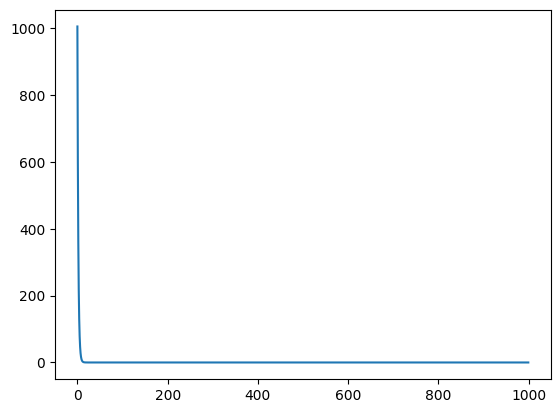

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([5, 7, 9, 11, 13, 15])
y = np.array([15, 21, 27, 33, 39, 45])

b = 0
w = 0
lr = 0.001
n = len(x)
cost = 0
losses = []

for i in range(1000):
    y_pred = w*x + b
    error = y_pred-y

    cost = np.mean(error**2)
    losses.append(cost)

    dw = (2/n)*np.sum(error*x)
    db = (2/n)*np.sum(error)

    w = w - lr*dw
    b = b - lr*db

print("weight:",w)
print("bias:",b)
print("cost:",cost)

plt.plot(losses)

### Gradient descendant from scratch

weight: 2.072226071990879
bias: 0.7876464608565451


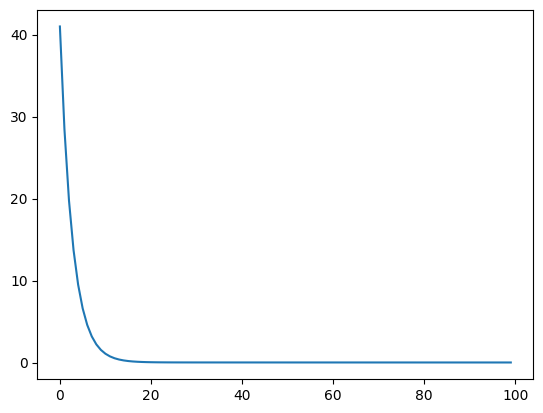

In [ ]:
import matplotlib.pyplot as plt

X = [1, 2, 3, 4]
Y = [3, 5, 7, 9]

w = 0
b = 0
lr = 0.01
cost = 0
loss = []

n = len(X)

for i in range(100):
    y_pred = []
    error = []
    lst = []
    lst2 = []
    for x in X:
        y_pred.append(w*x + b)
    for j in range(n):
        error.append(y_pred[j]-Y[j])
    for c in error:
        lst.append(c**2)
    cost = sum(lst) / n
    loss.append(cost)
    
    for k in range(n):
        lst2.append(error[k] * X[k])

    dw = (2/n)*sum(lst2)
    db = (2/n)*sum(error)

    w = w - lr*dw
    b = b - lr*db

print("weight:",w)
print("bias:",b)

plt.plot(loss)
plt.show()

### PCA using numpy

In [ ]:
import numpy as np

X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]])

X_centered = X-np.mean(X,axis=0)
cov_matrix = np.cov(X_centered,rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sorted_idx = np.argsort(eigenvalues)[::-1]
X_reduced = X_centered @ eigenvectors[:, sorted_idx[:1]]
print(X_reduced)

[[ 0.82797019]
 [-1.77758033]
 [ 0.99219749]
 [ 0.27421042]
 [ 1.67580142]
 [ 0.9129491 ]
 [-0.09910944]
 [-1.14457216]
 [-0.43804614]
 [-1.22382056]]


In [ ]:
import numpy as np
import pandas as pd

data = pd.read_csv("students.csv")
X = data.values
X_centered = X-np.mean(X,axis=0)
cov_matrix = np.cov(X_centered,rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sorted_ind = np.argsort(eigenvalues)[::-1]
reduced_data = X_centered @ eigenvectors[:,sorted_ind[:1]]
print(reduced_data)

[[-21.55708641]
 [ -9.99351473]
 [-33.20421781]
 [ 32.63182279]
 [ 16.14243056]
 [-38.29503478]
 [ 45.10958886]
 [-12.35438212]
 [ 20.40968596]
 [-28.01701885]
 [ 41.87776645]
 [ -2.80050789]
 [-17.74951241]
 [ 32.57912584]
 [-24.77914548]]


In [ ]:
X = [
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
]

n = len(X)
mean_x = sum(row[0] for row in X) / n
mean_y = sum(row[1] for row in X) / n

X_centered = []
for i in range(n):
    X_centered.append([X[i]-mean_x, Y[i]-mean_y])

var_x = sum((i[0]**2) for i in X_centered) / (n-1)
var_y = sum((i[1]**2) for i in X_centered) / (n-1)

cov_xy = sum((i[0]*i[1]) for i in X_centered) / (n-1)
cov_matrix = [[var_x, cov_xy],
              [cov_xy, var_y]]

a = cov_matrix[0][0]
b = cov_matrix[0][1]
c = cov_matrix[1][0]
d = cov_matrix[1][1]

trace = a+d
det = a*d - b*c

lambda1 = trace + (trace**2 - 4*(det)**2)**0.5 / 2
lambda2 = trace - (trace**2 - 4*(det)**2)**0.5 / 2

def eigenvectors(lam):
    x = 1
    y = -((a-lam) / b)
    return (x,y)

eigenvector1 = eigenvectors(lambda1)
eigenvector2 = eigenvectors(lambda2)

eigen_pairs = [[lambda1, eigenvector1],
               [lambda2, eigenvector2]]

eigen_pairs.sort(reverse=True, key=lambda x: x[0])

pc1 = eigen_pairs[0][1]
pc2 = eigen_pairs[1][1]

reduced_data = []
for i in X_centered:
    projection = i[0]*pc1[0] + i[1]*pc2[1]
    reduced_data.append(projection)

for i in reduced_data:
    print(i)

TypeError: unsupported operand type(s) for -: 'list' and 'float'

2.0125808140125887
1.9545792695438862


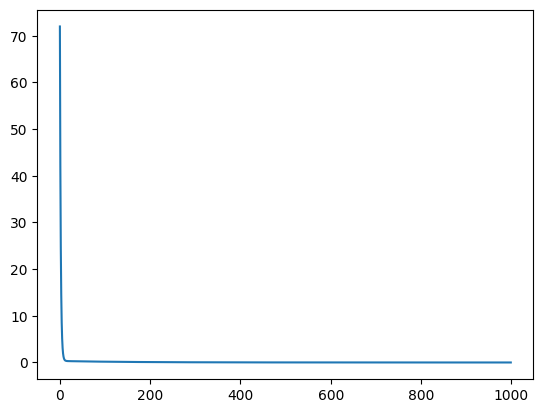

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,2,3,4,5])
y = np.array([4,6,8,10,12])

w = 0
b = 0
lr = 0.01
n = len(x)
cost = 0
loss = []

for i in range(1000):
    y_pred = w*x + b
    error = y_pred - y
    cost = np.mean(error**2)
    loss.append(cost)

    dw = (2/n)*np.sum(error*x)
    db = (2/n)*np.sum(error)

    w = w - lr*dw
    b = b - lr*db

print(w)
print(b)

plt.plot(loss)

In [ ]:
X = [
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
]

n = len(X)
mean_x = sum((i[0]) for i in X) / n
mean_y = sum((i[1]) for i in X) / n

X_centered = []
for i in X:
    X_centered.append([i[0]-mean_x, i[1]-mean_y])

var_x = sum((i[0]**2) for i in X_centered) / (n-1)
var_y = sum((i[1]**2) for i in X_centered) / (n-1)

cov_xy = sum((i[0] * i[1]) for i in X_centered) / (n-1)

cov_matrix = [[var_x, cov_xy],
              [cov_xy, var_y]]

a = cov_matrix[0][0]
b = cov_matrix[0][1]
c = cov_matrix[1][0]
d = cov_matrix[1][1]
trace = a+d
det = a*d - b*c

lambda1 = (trace + (trace**2 - 4*det)**0.5) / 2
lambda2 = (trace - (trace**2 - 4*det)**0.5) / 2

def eigenvectors(lam):
    if b!=0:
        x = 1
        y = -((a - lam) / b)
    else:
        x = 0
        y = 1
    return (x,y)

eigvect1 = eigenvectors(lambda1)
eigvect2 = eigenvectors(lambda2)

eigen_pairs = [[lambda1, eigvect1],
               [lambda2, eigvect2]]

eigen_pairs.sort(reverse=True, key=lambda x: x[0])
pc1 = eigen_pairs[0][1]
pc2 = eigen_pairs[1][1]

reduced_data = []
for i in X_centered:
    projection = i[0]*pc1[0] + i[1]*pc1[1]
    reduced_data.append(projection)

print(reduced_data)

[1.2214230385777172, -2.622289544242935, 1.4636914452896739, 0.4045156758929347, 2.472145126632065, 1.3467840826048911, -0.14620641216141317, -1.6884748188733698, -0.6462064121614132, -1.8053821815581523]


weight: 2.9805656272532244
bias: 0.21681573353346795


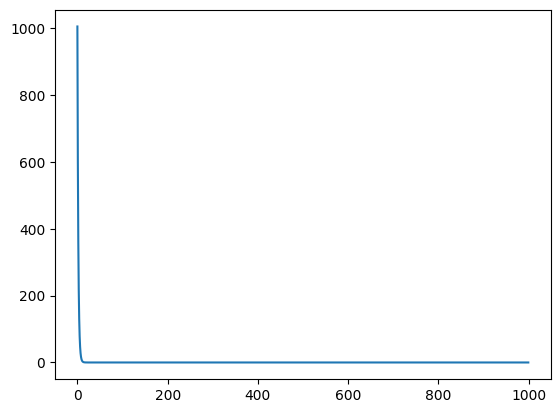

In [ ]:
import numpy as np
import pandas as pd

x = np.array([5, 7, 9, 11, 13, 15])
y = np.array([15, 21, 27, 33, 39, 45])

n = len(x)
w = 0
b = 0
lr = 0.001
cost = 0
losses = []

for i in range(1000):
    y_pred = w*x + b
    error = y_pred - y
    cost = np.mean(error**2)
    losses.append(cost)

    dw = (2/n)*np.sum(error*x)
    db = (2/n)*np.sum(error)

    w = w - lr*dw
    b = b - lr*db

print("weight:",w)
print("bias:",b)

plt.plot(losses)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

data = pd.DataFrame({
    "Student": ["A", "B", "C", "D", "E", "F"],
    "Subject": ["Math", "Math", "Science", "Science", "English", "English"],
    "Marks": [80, 90, 70, 85, 88, 92]
})

avg_marks = data.groupby("Subject")["Marks"].mean()
print(avg_marks)

Subject
English    90.0
Math       85.0
Science    77.5
Name: Marks, dtype: float64
